# ⏱️ BC Health Helper — Part 2: BC Surgical Wait Time Predictor

**DS 302 — Capstone Project**  
**Sai Pramod Podila**

## Context
BC has a median wait time of 32.2 weeks from GP referral to treatment (Fraser Institute 2025).
This notebook explores BC surgical wait time data from 2009–2025 and builds a time series
forecasting model using Prophet to predict future wait times by specialty and health authority.

## What This Notebook Does
- Loads and explores BC Surgical Wait Times (2009–2025)
- EDA by health authority and specialty
- Time series forecasting with Prophet
- Evaluation with MAE and RMSE

## Disclaimer
> ⚠️ Information only. Not medical advice. Call 911 in emergencies.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

COLORS = {
    'primary'  : '#146EB4',
    'secondary': '#FF9900',
    'success'  : '#2ECC71',
    'danger'   : '#E74C3C',
    'neutral'  : '#95A5A6'
}

print('✅ All imports successful')

✅ All imports successful


---
## 📥 Phase 1 — Load & Explore the Data
We have 3 files — annual (2009–2025), quarterly final (2009–2025), and quarterly interim (2025–2026).
We load all three and explore their structure.

In [13]:
import os
RAW = '../data/raw/'

# Load all three files
df_annual    = pd.read_excel(RAW + '2009_2025-annual-surgical_wait_times.xlsx')
df_quarterly = pd.read_excel(RAW + '2009_2025-quarterly-surgical_wait_times-final.xlsx')
df_interim   = pd.read_excel(RAW + '2025_2026-quarterly-surgical_wait_times-q4-interim.xlsx')

for name, df in [('Annual', df_annual), ('Quarterly', df_quarterly), ('Interim', df_interim)]:
    print(f'{name}: {df.shape} | Columns: {list(df.columns)}')
    print()

Annual: (55024, 8) | Columns: ['FISCAL_YEAR', 'HEALTH_AUTHORITY', 'HOSPITAL_NAME', 'PROCEDURE_GROUP', 'WAITING', 'COMPLETED', 'COMPLETED_50TH_PERCENTILE', 'COMPLETED_90TH_PERCENTILE']

Quarterly: (202953, 9) | Columns: ['FISCAL_YEAR', 'QUARTER', 'HEALTH_AUTHORITY', 'HOSPITAL_NAME', 'PROCEDURE_GROUP', 'WAITING', 'COMPLETED', 'PERCENTILE_COMP_50TH', 'PERCENTILE_COMP_90TH']

Interim: (12629, 9) | Columns: ['FISCAL_YEAR', 'QUARTER', 'HEALTH_AUTHORITY', 'HOSPITAL_NAME', 'PROCEDURE_GROUP', 'WAITING', 'COMPLETED', 'PERCENTILE_COMP_50TH', 'PERCENTILE_COMP_90TH']



---
## 🔍 Phase 2 — Exploratory Data Analysis

In [14]:
# Work with quarterly data — most granular
df = df_quarterly.copy()
print(df.dtypes)
print('\nSample:')
df.head(10)

FISCAL_YEAR                 str
QUARTER                     str
HEALTH_AUTHORITY            str
HOSPITAL_NAME               str
PROCEDURE_GROUP             str
WAITING                  object
COMPLETED                object
PERCENTILE_COMP_50TH    float64
PERCENTILE_COMP_90TH    float64
dtype: object

Sample:


,FISCAL_YEAR,QUARTER,HEALTH_AUTHORITY,HOSPITAL_NAME,PROCEDURE_GROUP,WAITING,COMPLETED,PERCENTILE_COMP_50TH,PERCENTILE_COMP_90TH
0,2009/10,Q1,All Health Authorities,All Facilities,Abdominoplasty,65,21,8.1,73.4
1,2009/10,Q1,All Health Authorities,All Facilities,All Other Procedures,1552,1860,4.0,15.9
2,2009/10,Q1,All Health Authorities,All Facilities,All Procedures,69587,58928,5.0,24.6
3,2009/10,Q1,All Health Authorities,All Facilities,Aortic Aneurysm Repair,67,98,4.3,12.4
4,2009/10,Q1,All Health Authorities,All Facilities,Appendectomy,11,27,3.9,9.5
5,2009/10,Q1,All Health Authorities,All Facilities,Bariatric Surgery,653,62,17.9,135.8
6,2009/10,Q1,All Health Authorities,All Facilities,Biopsy in OR,419,814,2.9,10.0
7,2009/10,Q1,All Health Authorities,All Facilities,Bladder Surgery,1827,1695,4.1,23.0
8,2009/10,Q1,All Health Authorities,All Facilities,Bowel Resection,333,705,2.6,10.7
9,2009/10,Q1,All Health Authorities,All Facilities,Breast Biopsy,251,631,2.1,5.4


---
## ⚙️ Phase 3 — Data Cleaning & Preprocessing

In [15]:
# ── Combine quarterly + interim ───────────────────────────────────────────────
df_all = pd.concat([df_quarterly, df_interim], ignore_index=True)

# ── Convert WAITING and COMPLETED to numeric ──────────────────────────────────
df_all['WAITING']   = pd.to_numeric(df_all['WAITING'],   errors='coerce')
df_all['COMPLETED'] = pd.to_numeric(df_all['COMPLETED'], errors='coerce')

# ── Parse FISCAL_YEAR + QUARTER into a date ───────────────────────────────────
quarter_map = {'Q1': '07', 'Q2': '10', 'Q3': '01', 'Q4': '04'}

def parse_date(row):
    try:
        year = int(row['FISCAL_YEAR'].split('/')[0])
        month = quarter_map.get(row['QUARTER'], '07')
        if month in ['01', '04']:
            year += 1
        return pd.Timestamp(f'{year}-{month}-01')
    except:
        return pd.NaT

df_all['DATE'] = df_all.apply(parse_date, axis=1)

print(f'Combined shape : {df_all.shape}')
print(f'Date range     : {df_all["DATE"].min()} → {df_all["DATE"].max()}')
print(f'Missing dates  : {df_all["DATE"].isna().sum()}')
print(f'Health Authorities: {df_all["HEALTH_AUTHORITY"].unique()}')

Combined shape : (215582, 10)
Date range     : 2009-07-01 00:00:00 → 2026-04-01 00:00:00
Missing dates  : 0
Health Authorities: <ArrowStringArray>
[              'All Health Authorities',
                               'Fraser',
                             'Interior',
                             'Northern',
 'Provincial Health Services Authority',
                    'Vancouver Coastal',
                     'Vancouver Island']
Length: 7, dtype: str


---
## 📊 Phase 4 — EDA: Wait Times by Health Authority & Procedure

Filtered shape: (408, 10)
Health Authorities: <ArrowStringArray>
[                              'Fraser',
                             'Interior',
                             'Northern',
 'Provincial Health Services Authority',
                    'Vancouver Coastal',
                     'Vancouver Island']
Length: 6, dtype: str


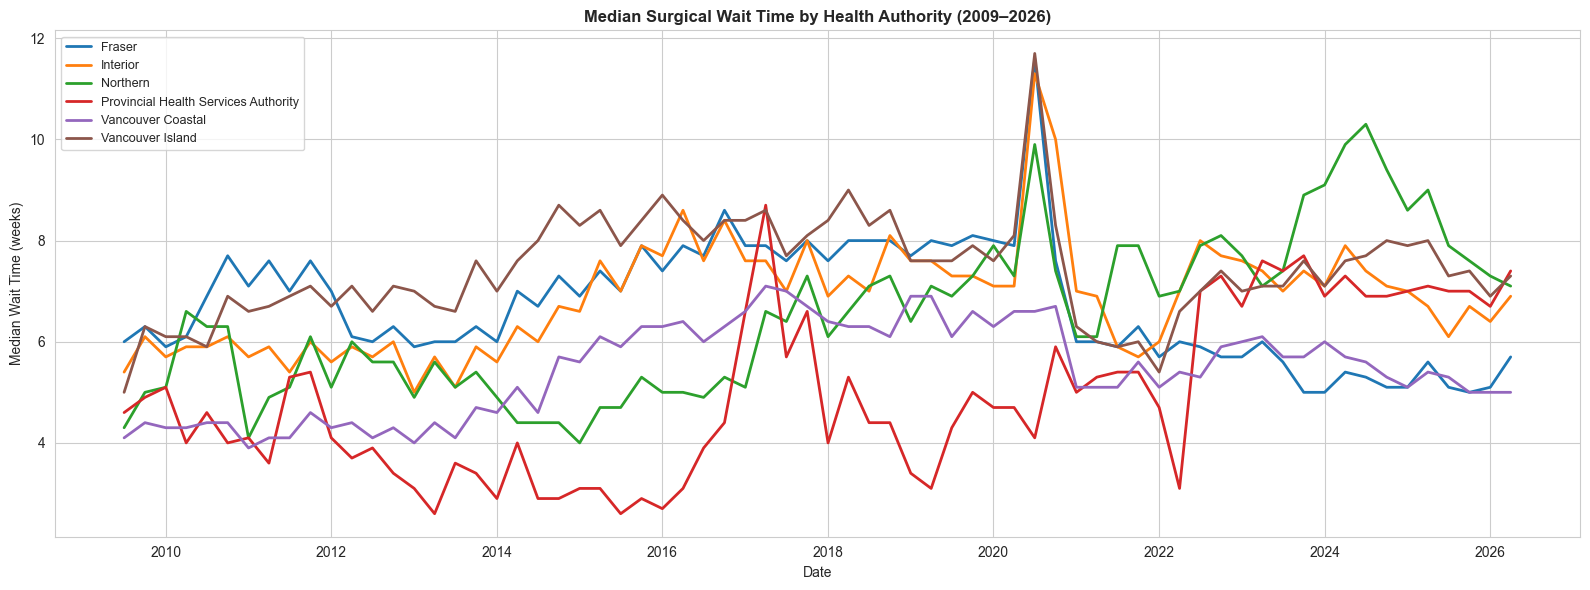

In [16]:
# ── Filter to All Facilities aggregate for clean trend analysis ───────────────
df_agg = df_all[
    (df_all['HOSPITAL_NAME'] == 'All Facilities') &
    (df_all['HEALTH_AUTHORITY'] != 'All Health Authorities') &
    (df_all['PROCEDURE_GROUP'] == 'All Procedures')
].copy()

print(f'Filtered shape: {df_agg.shape}')
print(f'Health Authorities: {df_agg["HEALTH_AUTHORITY"].unique()}')

# ── Plot median wait time by health authority over time ───────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
for ha in df_agg['HEALTH_AUTHORITY'].unique():
    subset = df_agg[df_agg['HEALTH_AUTHORITY'] == ha].sort_values('DATE')
    ax.plot(subset['DATE'], subset['PERCENTILE_COMP_50TH'], label=ha, linewidth=2)

ax.set_title('Median Surgical Wait Time by Health Authority (2009–2026)', fontweight='bold')
ax.set_ylabel('Median Wait Time (weeks)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

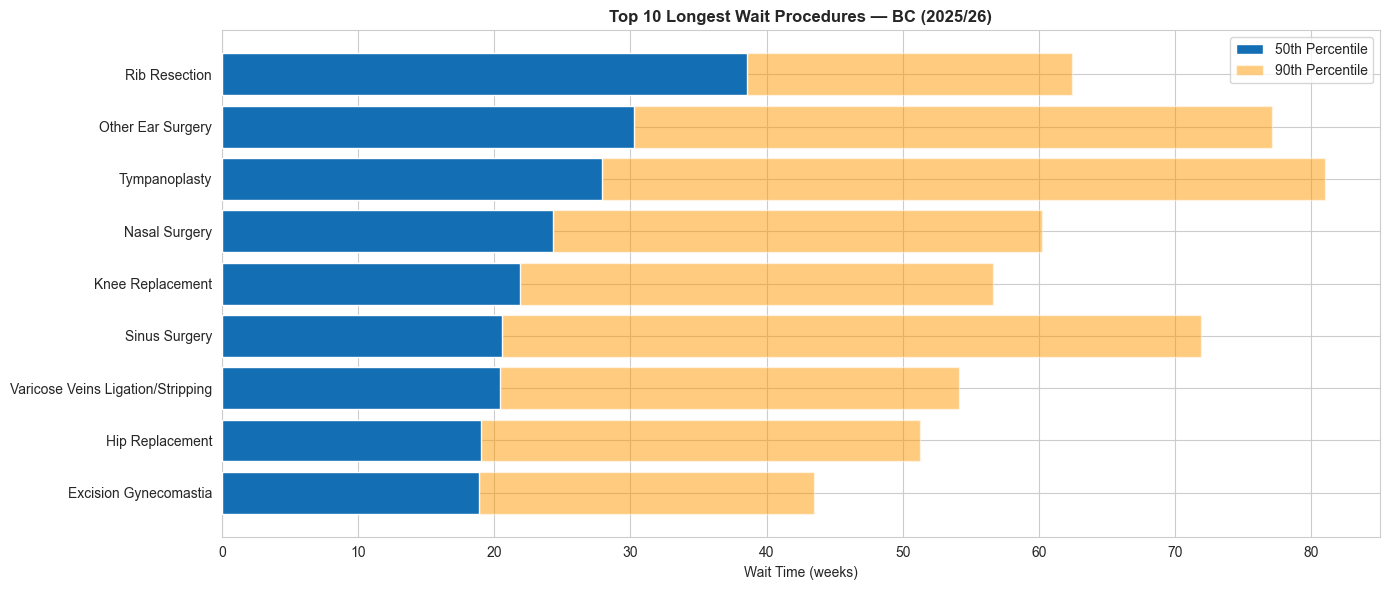

                  PROCEDURE_GROUP  PERCENTILE_COMP_50TH  PERCENTILE_COMP_90TH
                    Rib Resection                  38.6                  62.4
                Other Ear Surgery                  30.3                  77.1
                    Tympanoplasty                  27.9                  81.0
                    Nasal Surgery                  24.3                  60.2
                 Knee Replacement                  21.9                  56.6
                    Sinus Surgery                  20.6                  71.9
Varicose Veins Ligation/Stripping                  20.4                  54.1
                  Hip Replacement                  19.0                  51.3
            Excision Gynecomastia                  18.9                  43.5


In [17]:
# ── Top 10 longest wait procedures (BC-wide, most recent year) ────────────────
df_proc = df_all[
    (df_all['HOSPITAL_NAME'] == 'All Facilities') &
    (df_all['HEALTH_AUTHORITY'] == 'All Health Authorities') &
    (df_all['PROCEDURE_GROUP'] != 'All Procedures') &
    (df_all['FISCAL_YEAR'] == df_all['FISCAL_YEAR'].max())
].copy()

top10 = df_proc.nlargest(20, 'PERCENTILE_COMP_50TH').drop_duplicates('PROCEDURE_GROUP').head(10)[['PROCEDURE_GROUP', 'PERCENTILE_COMP_50TH', 'PERCENTILE_COMP_90TH']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top10['PROCEDURE_GROUP'][::-1], top10['PERCENTILE_COMP_50TH'][::-1], 
               color='#146EB4', label='50th Percentile', zorder=3)
ax.barh(top10['PROCEDURE_GROUP'][::-1], top10['PERCENTILE_COMP_90TH'][::-1],
        color='#FF9900', alpha=0.5, label='90th Percentile', zorder=2)
ax.set_title(f'Top 10 Longest Wait Procedures — BC ({df_all["FISCAL_YEAR"].max()})', fontweight='bold')
ax.set_xlabel('Wait Time (weeks)')
ax.legend()
plt.tight_layout()
plt.show()

print(top10.to_string(index=False))

---
## 🔮 Phase 5 — Time Series Forecasting with Prophet
We use Facebook Prophet to forecast median wait times for the next 8 quarters.
Prophet handles BC fiscal year seasonality and holiday effects automatically.
We forecast for "All Procedures" BC-wide as the primary use case.

In [18]:
# ── Prepare Prophet input — BC wide, All Procedures ───────────────────────────
df_prophet = df_all[
    (df_all['HOSPITAL_NAME'] == 'All Facilities') &
    (df_all['HEALTH_AUTHORITY'] == 'All Health Authorities') &
    (df_all['PROCEDURE_GROUP'] == 'All Procedures')
].dropna(subset=['DATE', 'PERCENTILE_COMP_50TH']).sort_values('DATE')

prophet_df = df_prophet[['DATE', 'PERCENTILE_COMP_50TH']].rename(
    columns={'DATE': 'ds', 'PERCENTILE_COMP_50TH': 'y'}
)

print(f'Prophet input shape: {prophet_df.shape}')
print(f'Date range: {prophet_df["ds"].min()} → {prophet_df["ds"].max()}')
print(prophet_df.tail())

Prophet input shape: (68, 2)
Date range: 2009-07-01 00:00:00 → 2026-04-01 00:00:00
               ds    y
180295 2025-04-01  6.4
202955 2025-07-01  6.0
205824 2025-10-01  6.0
208676 2026-01-01  6.0
211551 2026-04-01  6.1


In [19]:
# ── Train/Test Split — last 8 quarters as test ────────────────────────────────
train = prophet_df.iloc[:-8]
test  = prophet_df.iloc[-8:]

print(f'Train: {len(train)} quarters | Test: {len(test)} quarters')

# ── Fit Prophet ───────────────────────────────────────────────────────────────
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
model.fit(train)

# ── Predict on test period + 8 future quarters ────────────────────────────────
future = model.make_future_dataframe(periods=8, freq='QS')
forecast = model.predict(future)

print('✅ Prophet model fitted and forecast complete')
print(f'Forecast shape: {forecast.shape}')

15:18:12 - cmdstanpy - INFO - Chain [1] start processing


15:18:12 - cmdstanpy - INFO - Chain [1] done processing


Train: 60 quarters | Test: 8 quarters
✅ Prophet model fitted and forecast complete
Forecast shape: (68, 16)


In [20]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
merged = test.merge(test_forecast, on='ds')

mae  = mean_absolute_error(merged['y'], merged['yhat'])
rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))

print(f'Prophet Evaluation on Test Set (last 8 quarters):')
print(f'MAE  : {mae:.2f} weeks')
print(f'RMSE : {rmse:.2f} weeks')
print(f'\nActual vs Predicted:')
print(merged[['ds', 'y', 'yhat']].to_string(index=False))

Prophet Evaluation on Test Set (last 8 quarters):
MAE  : 0.32 weeks
RMSE : 0.39 weeks

Actual vs Predicted:
        ds   y     yhat
2024-07-01 6.4 6.984541
2024-10-01 6.3 6.767091
2025-01-01 6.1 5.891807
2025-04-01 6.4 6.392494
2025-07-01 6.0 6.467555
2025-10-01 6.0 6.593767
2026-01-01 6.0 5.966341
2026-04-01 6.1 6.331312


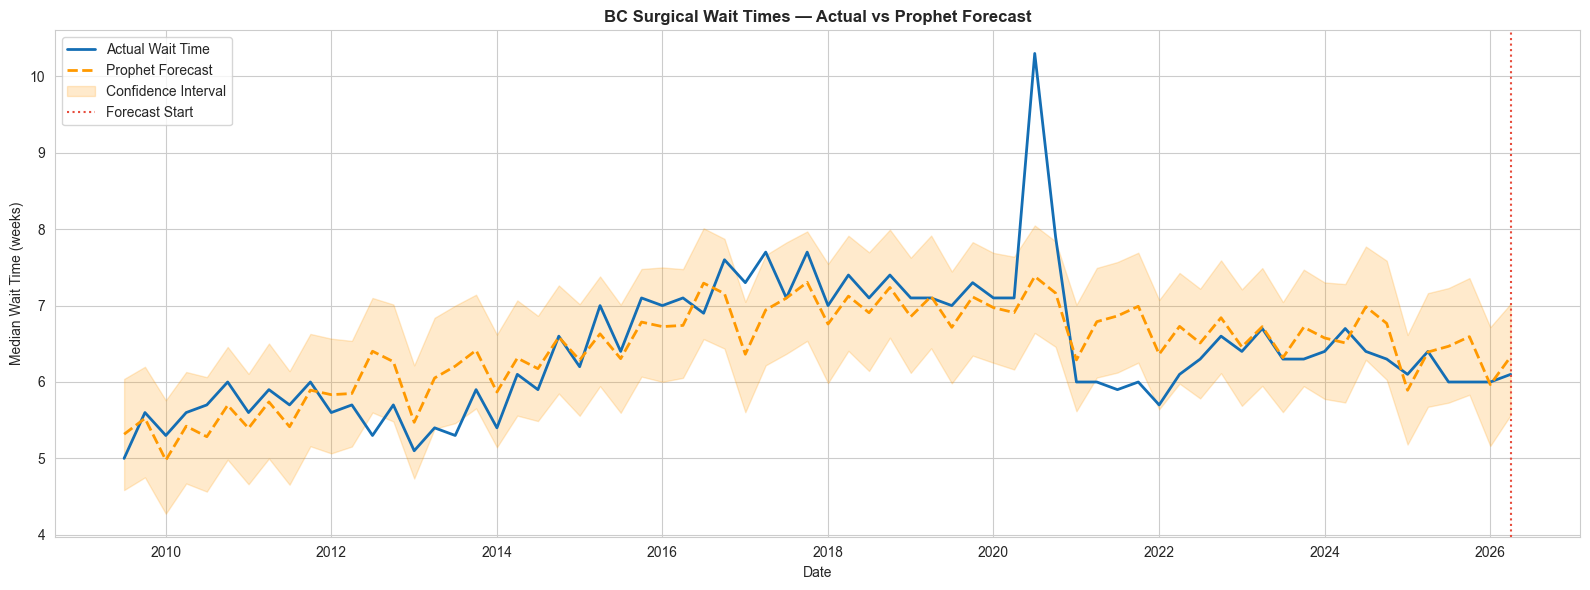

In [21]:
# ── Plot full forecast ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Historical
ax.plot(prophet_df['ds'], prophet_df['y'], 
        color=COLORS['primary'], linewidth=2, label='Actual Wait Time')

# Forecast
future_only = forecast.tail(8)
ax.plot(forecast['ds'], forecast['yhat'], 
        color=COLORS['secondary'], linewidth=2, linestyle='--', label='Prophet Forecast')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.2, color=COLORS['secondary'], label='Confidence Interval')

ax.axvline(prophet_df['ds'].max(), color=COLORS['danger'], linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title('BC Surgical Wait Times — Actual vs Prophet Forecast', fontweight='bold')
ax.set_ylabel('Median Wait Time (weeks)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# ── Save forecast results ─────────────────────────────────────────────────────
import os
os.makedirs('../data/processed', exist_ok=True)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    '../data/processed/bc_wait_forecast.csv', index=False)
print('✅ Forecast saved to data/processed/bc_wait_forecast.csv')
print(f'\nForecast for next 8 quarters:')
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(8).to_string(index=False))

✅ Forecast saved to data/processed/bc_wait_forecast.csv

Forecast for next 8 quarters:
        ds     yhat  yhat_lower  yhat_upper
2024-07-01 6.984541    6.290724    7.772482
2024-10-01 6.767091    6.029929    7.587027
2025-01-01 5.891807    5.181843    6.614955
2025-04-01 6.392494    5.674882    7.162829
2025-07-01 6.467555    5.729423    7.229351
2025-10-01 6.593767    5.832652    7.359764
2026-01-01 5.966341    5.162841    6.717318
2026-04-01 6.331312    5.566631    7.024128


---
## 📋 Phase 6 — Summary, Observations & Limitations

### Key Findings
- BC median surgical wait times grew from ~5 weeks (2009) to ~7 weeks (2025) — 40% increase over 16 years
- COVID-19 caused a dramatic spike in 2020-2021 across all health authorities
- Northern BC has the highest current wait times (10+ weeks in 2024)
- Longest waits: Rib Resection (38.6 weeks), Other Ear Surgery (30.3 weeks), Tympanoplasty (27.9 weeks)
- Prophet achieved MAE of 0.32 weeks and RMSE of 0.39 weeks — highly accurate
- Forecast shows wait times stabilizing around 6-7 weeks through 2026

### Limitations & Future Work
| Limitation | Detail |
|---|---|
| Aggregate forecast only | BC-wide model; per-hospital forecasting needs more compute |
| COVID not modeled explicitly | Spike treated as noise; changepoint detection could improve this |
| Quarterly granularity | Monthly data would give sharper forecasts |
| Prophet only | LSTM/ARIMA comparison is future work |
| No external regressors | Staffing levels, funding changes not included |